# Count Significance playground

This notebook introduces the two counting models used in the companion paper. Run it from an editable installation (`python3 -m pip install -e .`).

Each example is self-contained and uses one signal value. Change the value assigned to `s0` or `s_true` near the top of a cell, then rerun that cell to explore another hypothesis.

The observed-data examples use $s_0$ for the signal value being tested. The expected-significance examples use $s_{\mathrm{true}}$ for the signal that generates the data. For discovery, $s_0=0$ and the one-sided statistics are $q_0=[\max(0,r)]^2$ and $q_0^\ast=[\max(0,r^\ast)]^2$. Every p-value is also shown as the equivalent Gaussian significance $Z=\Phi^{-1}(1-p)$.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from count_significance import (
    expected_significance_on,
    expected_significance_onoff,
    pvals_on,
    pvals_onoff_profile_sum,
)


# Convert one-sided p-values to finite Gaussian significances for plotting.
def significance_from_p(p_values):
    p_values = np.asarray(p_values, dtype=float)
    return norm.isf(np.clip(p_values, np.finfo(float).tiny, 0.5))

## Known background

Here $N\sim\mathrm{Pois}(s+b)$ and the background $b$ is known. The reference p-value is the inclusive Poisson tail $P(N\geq n\mid s_0+b)$, capped at $0.5$ by the one-sided convention.

### Observed test: $s_0=0$

This is the usual discovery test. To test another signal value, edit only `s0` in the next cell.

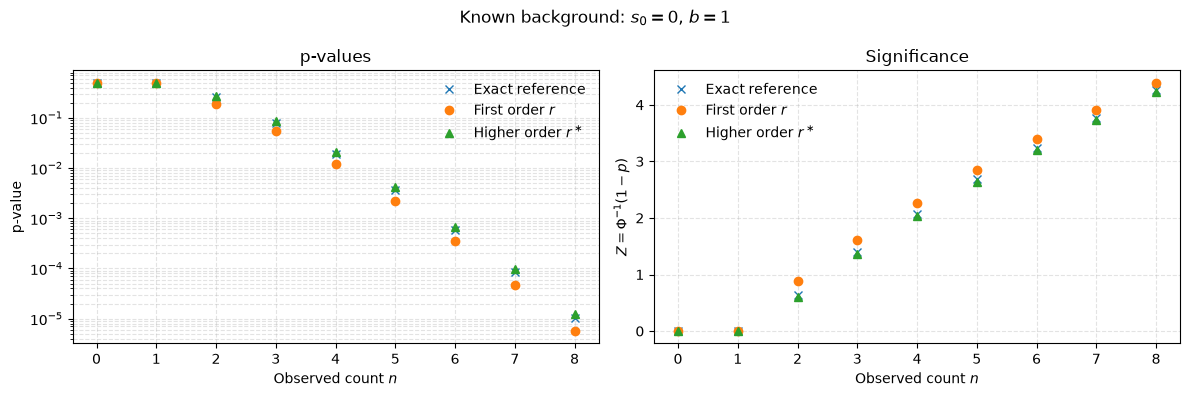

In [11]:
# Choose the tested signal, known background and observed-count range.
s0 = 0.0
background = 1.0
n_values = np.arange(0, 9)

pvalues = pvals_on(s0, background, n_values)
p_exact = pvalues["p_exact"]
p_r = pvalues["p_r"]
p_rstar = pvalues["p_rstar"]

z_exact = significance_from_p(p_exact)
z_r = significance_from_p(p_r)
z_rstar = significance_from_p(p_rstar)

fig, (ax_p, ax_z) = plt.subplots(1, 2, figsize=(12, 4))

ax_p.semilogy(n_values, p_exact, "x", linestyle="none", label="Exact reference")
ax_p.semilogy(n_values, p_r, "o", linestyle="none", label=r"First order $r$")
ax_p.semilogy(
    n_values, p_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_p.set(xlabel=r"Observed count $n$", ylabel="p-value", title="p-values")
ax_p.grid(True, which="both", linestyle="--", alpha=0.35)
ax_p.legend(frameon=False)

ax_z.plot(n_values, z_exact, "x", linestyle="none", label="Exact reference")
ax_z.plot(n_values, z_r, "o", linestyle="none", label=r"First order $r$")
ax_z.plot(
    n_values, z_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_z.set(
    xlabel=r"Observed count $n$",
    ylabel=r"$Z=\Phi^{-1}(1-p)$",
    title="Significance",
)
ax_z.grid(True, linestyle="--", alpha=0.35)
ax_z.legend(frameon=False)

fig.suptitle(rf"Known background: $s_0={s0:g}$, $b={background:g}$")
fig.tight_layout()
plt.show()

**What this output shows.** The two panels contain the same information on p-value and Gaussian-significance scales. The $p=0.5$ plateau corresponds to $Z=0$, while the three marker sets compare the discrete reference tail with its first- and higher-order approximations.

### Observed test: $s_0=1$

This repeats the same calculation for a non-zero tested signal. The plotting commands are written out explicitly so that the cell can be copied and edited independently.

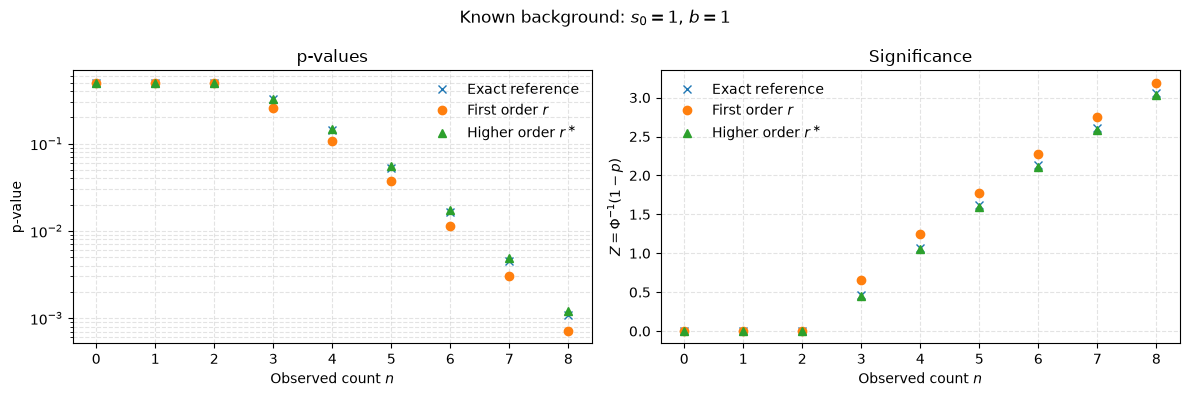

In [12]:
# Change this value to test another signal hypothesis.
s0 = 1.0
background = 1.0
n_values = np.arange(0, 9)

pvalues = pvals_on(s0, background, n_values)
p_exact = pvalues["p_exact"]
p_r = pvalues["p_r"]
p_rstar = pvalues["p_rstar"]

z_exact = significance_from_p(p_exact)
z_r = significance_from_p(p_r)
z_rstar = significance_from_p(p_rstar)

fig, (ax_p, ax_z) = plt.subplots(1, 2, figsize=(12, 4))

ax_p.semilogy(n_values, p_exact, "x", linestyle="none", label="Exact reference")
ax_p.semilogy(n_values, p_r, "o", linestyle="none", label=r"First order $r$")
ax_p.semilogy(
    n_values, p_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_p.set(xlabel=r"Observed count $n$", ylabel="p-value", title="p-values")
ax_p.grid(True, which="both", linestyle="--", alpha=0.35)
ax_p.legend(frameon=False)

ax_z.plot(n_values, z_exact, "x", linestyle="none", label="Exact reference")
ax_z.plot(n_values, z_r, "o", linestyle="none", label=r"First order $r$")
ax_z.plot(
    n_values, z_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_z.set(
    xlabel=r"Observed count $n$",
    ylabel=r"$Z=\Phi^{-1}(1-p)$",
    title="Significance",
)
ax_z.grid(True, linestyle="--", alpha=0.35)
ax_z.legend(frameon=False)

fig.suptitle(rf"Known background: $s_0={s0:g}$, $b={background:g}$")
fig.tight_layout()
plt.show()

**What this output shows.** Here the tested mean is $s_0+b=2$. Increasing $s_0$ moves the upper tail towards larger counts, so the one-sided values remain at $p=0.5$ and $Z=0$ until the observation exceeds the tested mean.

### Expected discovery significance

These cells test $s_0=0$ but generate observations with the selected `s_true`. The Asimov results are shown as continuous first- and higher-order curves, while the Monte Carlo medians remain discrete points.

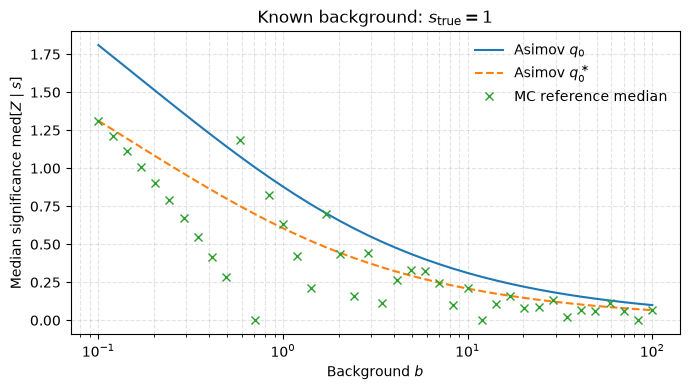

In [13]:
# Change this value to study another true signal.
s_true = 1.0
b_values = np.logspace(-1, 2, 40)

summary = expected_significance_on(s_true, b_values, n_outer=500, seed=12345)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_values, summary["Z_A_r"], label=r"Asimov $q_0$")
ax.plot(
    b_values,
    summary["Z_A_rstar"],
    "--",
    label=r"Asimov $q_0^\ast$",
)
ax.plot(
    b_values,
    summary["Z_mc_median"],
    "x",
    linestyle="none",
    label="MC reference median",
)
ax.set(
    xscale="log",
    xlabel=r"Background $b$",
    ylabel=r"Median significance $\mathrm{med}[Z\mid s]$",
    title=rf"Known background: $s_{{\mathrm{{true}}}}={s_true:g}$",
)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**What this output shows.** For $s_{\mathrm{true}}=1$, the Asimov curves approximate the typical sensitivity and the Monte Carlo points retain the discreteness of the Poisson observations. Increase `n_outer` if a smoother Monte Carlo estimate is needed.

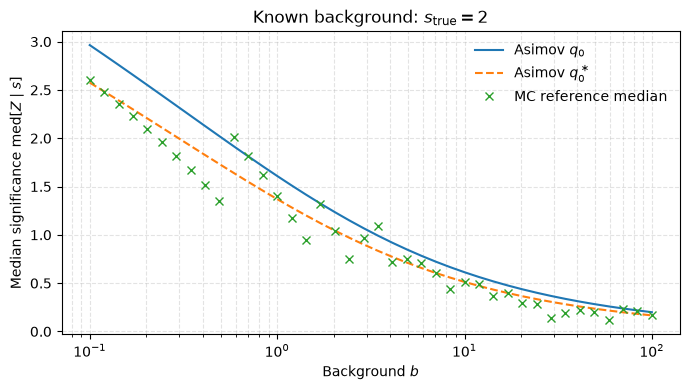

In [14]:
# This independent example uses a larger true signal.
s_true = 2.0
b_values = np.logspace(-1, 2, 40)

summary = expected_significance_on(s_true, b_values, n_outer=500, seed=12346)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_values, summary["Z_A_r"], label=r"Asimov $q_0$")
ax.plot(
    b_values,
    summary["Z_A_rstar"],
    "--",
    label=r"Asimov $q_0^\ast$",
)
ax.plot(
    b_values,
    summary["Z_mc_median"],
    "x",
    linestyle="none",
    label="MC reference median",
)
ax.set(
    xscale="log",
    xlabel=r"Background $b$",
    ylabel=r"Median significance $\mathrm{med}[Z\mid s]$",
    title=rf"Known background: $s_{{\mathrm{{true}}}}={s_true:g}$",
)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**What this output shows.** Repeating the calculation with $s_{\mathrm{true}}=2$ generally increases the expected discovery significance. This cell can be edited without changing or rerunning the $s_{\mathrm{true}}=1$ example.

## On/off measurement

The uncertain-background model is $N\sim\mathrm{Pois}(s+b)$ and $M\sim\mathrm{Pois}(\tau b)$. The OFF count $m$ constrains the unknown background. Here `profile_sum` fixes the background to its estimate under the tested signal and deterministically sums the inclusive joint-Poisson tail.

The p-value routine accepts one observed pair $(n,m)$ at a time, so each scan uses a short list comprehension to evaluate the selected ON counts. The plotting itself remains fully explicit.

### Observed test: $s_0=0$

This is the on/off discovery test for a fixed observed OFF count and exposure ratio.

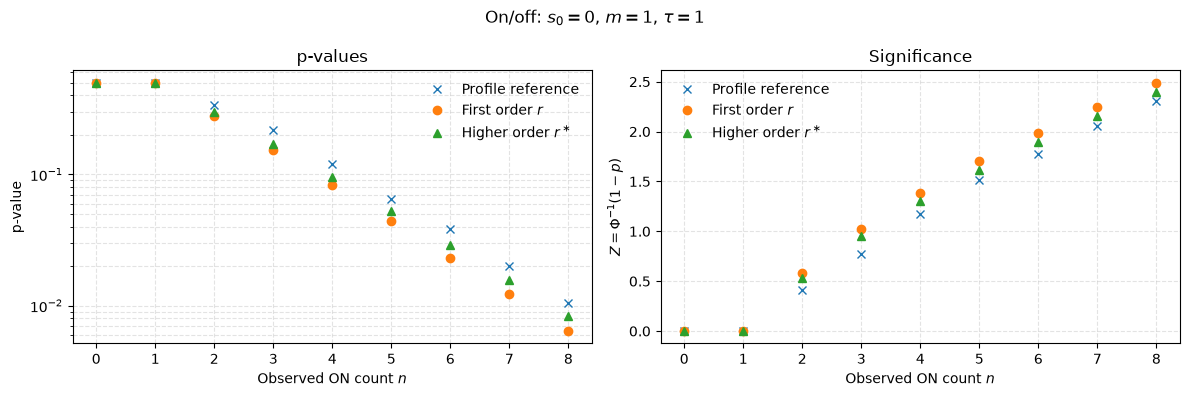

In [15]:
# Choose the tested signal and the observed on/off settings.
s0 = 0.0
m_observed = 1
tau = 1.0
n_values = np.arange(0, 9)

results = [
    pvals_onoff_profile_sum(s=s0, n=int(n), m=m_observed, tau=tau)
    for n in n_values
]
p_reference = np.array([result["p_ref"] for result in results])
p_r = np.array([result["p_r"] for result in results])
p_rstar = np.array([result["p_rstar"] for result in results])

z_reference = significance_from_p(p_reference)
z_r = significance_from_p(p_r)
z_rstar = significance_from_p(p_rstar)

fig, (ax_p, ax_z) = plt.subplots(1, 2, figsize=(12, 4))

ax_p.semilogy(
    n_values, p_reference, "x", linestyle="none", label="Profile reference"
)
ax_p.semilogy(n_values, p_r, "o", linestyle="none", label=r"First order $r$")
ax_p.semilogy(
    n_values, p_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_p.set(xlabel=r"Observed ON count $n$", ylabel="p-value", title="p-values")
ax_p.grid(True, which="both", linestyle="--", alpha=0.35)
ax_p.legend(frameon=False)

ax_z.plot(
    n_values, z_reference, "x", linestyle="none", label="Profile reference"
)
ax_z.plot(n_values, z_r, "o", linestyle="none", label=r"First order $r$")
ax_z.plot(
    n_values, z_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_z.set(
    xlabel=r"Observed ON count $n$",
    ylabel=r"$Z=\Phi^{-1}(1-p)$",
    title="Significance",
)
ax_z.grid(True, linestyle="--", alpha=0.35)
ax_z.legend(frameon=False)

fig.suptitle(rf"On/off: $s_0={s0:g}$, $m={m_observed}$, $\tau={tau:g}$")
fig.tight_layout()
plt.show()

**What this output shows.** With $m$ fixed, increasing $n$ produces stronger evidence for a positive signal. The profile reference is deterministic, but it plugs in a separately profiled background at each point rather than treating the nuisance parameter exactly.

### Observed test: $s_0=1$

This independent cell repeats the on/off calculation for a non-zero tested signal.

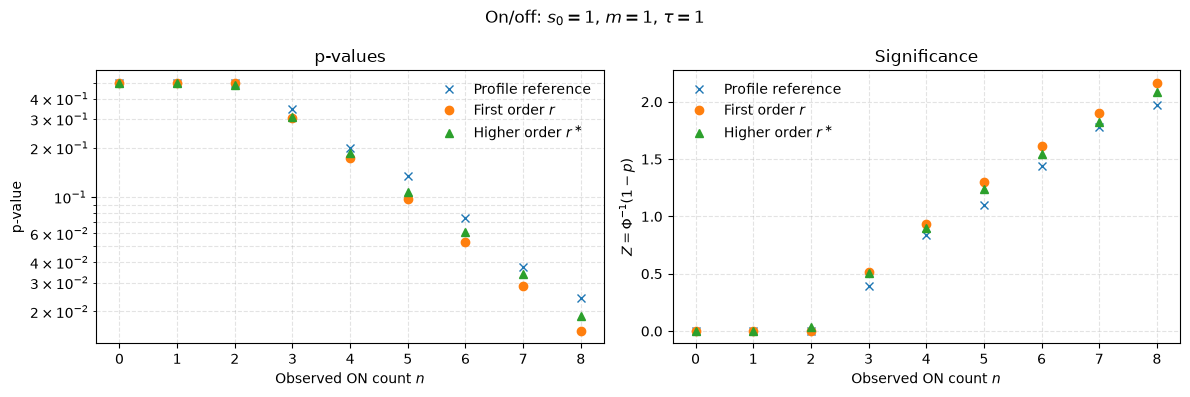

In [16]:
# Change this value to test another signal hypothesis.
s0 = 1.0
m_observed = 1
tau = 1.0
n_values = np.arange(0, 9)

results = [
    pvals_onoff_profile_sum(s=s0, n=int(n), m=m_observed, tau=tau)
    for n in n_values
]
p_reference = np.array([result["p_ref"] for result in results])
p_r = np.array([result["p_r"] for result in results])
p_rstar = np.array([result["p_rstar"] for result in results])

z_reference = significance_from_p(p_reference)
z_r = significance_from_p(p_r)
z_rstar = significance_from_p(p_rstar)

fig, (ax_p, ax_z) = plt.subplots(1, 2, figsize=(12, 4))

ax_p.semilogy(
    n_values, p_reference, "x", linestyle="none", label="Profile reference"
)
ax_p.semilogy(n_values, p_r, "o", linestyle="none", label=r"First order $r$")
ax_p.semilogy(
    n_values, p_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_p.set(xlabel=r"Observed ON count $n$", ylabel="p-value", title="p-values")
ax_p.grid(True, which="both", linestyle="--", alpha=0.35)
ax_p.legend(frameon=False)

ax_z.plot(
    n_values, z_reference, "x", linestyle="none", label="Profile reference"
)
ax_z.plot(n_values, z_r, "o", linestyle="none", label=r"First order $r$")
ax_z.plot(
    n_values, z_rstar, "^", linestyle="none", label=r"Higher order $r^\ast$"
)
ax_z.set(
    xlabel=r"Observed ON count $n$",
    ylabel=r"$Z=\Phi^{-1}(1-p)$",
    title="Significance",
)
ax_z.grid(True, linestyle="--", alpha=0.35)
ax_z.legend(frameon=False)

fig.suptitle(rf"On/off: $s_0={s0:g}$, $m={m_observed}$, $\tau={tau:g}$")
fig.tight_layout()
plt.show()

**What this output shows.** Testing $s_0=1$ shifts the one-sided tail towards larger ON counts.

### Expected discovery significance

The following examples mirror the known-background calculation. They use a deliberately modest grid and toy count so that each cell runs quickly on a laptop. Use the production configuration for publication-level Monte Carlo precision.

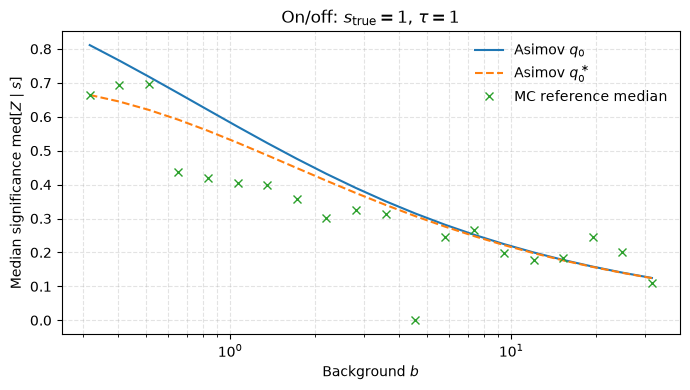

In [17]:
# Change this value to study another true signal.
s_true = 1.0
tau = 1.0
b_values = np.logspace(-0.5, 1.5, 20)

summary = expected_significance_onoff(
    s_true,
    b_values,
    tau=tau,
    n_outer=200,
    sigrel=0.10,
    min_toys=2000,
    max_toys=50000,
    seed=12345,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_values, summary["Z_A_r"], label=r"Asimov $q_0$")
ax.plot(
    b_values,
    summary["Z_A_rstar"],
    "--",
    label=r"Asimov $q_0^\ast$",
)
ax.plot(
    b_values,
    summary["Z_mc_median"],
    "x",
    linestyle="none",
    label="MC reference median",
)
ax.set(
    xscale="log",
    xlabel=r"Background $b$",
    ylabel=r"Median significance $\mathrm{med}[Z\mid s]$",
    title=rf"On/off: $s_{{\mathrm{{true}}}}={s_true:g}$, $\tau={tau:g}$",
)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**What this output shows.** The OFF measurement makes the background uncertain. The Asimov curves are deterministic approximations, while the Monte Carlo median retains visible discreteness and sampling noise at these tutorial settings.

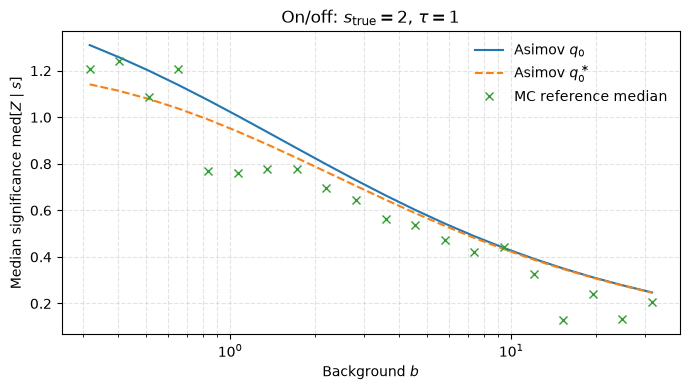

In [18]:
# This independent example uses a larger true signal.
s_true = 2.0
tau = 1.0
b_values = np.logspace(-0.5, 1.5, 20)

summary = expected_significance_onoff(
    s_true,
    b_values,
    tau=tau,
    n_outer=200,
    sigrel=0.10,
    min_toys=2000,
    max_toys=50000,
    seed=12346,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(b_values, summary["Z_A_r"], label=r"Asimov $q_0$")
ax.plot(
    b_values,
    summary["Z_A_rstar"],
    "--",
    label=r"Asimov $q_0^\ast$",
)
ax.plot(
    b_values,
    summary["Z_mc_median"],
    "x",
    linestyle="none",
    label="MC reference median",
)
ax.set(
    xscale="log",
    xlabel=r"Background $b$",
    ylabel=r"Median significance $\mathrm{med}[Z\mid s]$",
    title=rf"On/off: $s_{{\mathrm{{true}}}}={s_true:g}$, $\tau={tau:g}$",
)
ax.grid(True, which="both", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**What this output shows.** The larger true signal generally produces greater expected discovery significance. Edit `s_true`, `tau`, the background grid, or the toy settings in this cell without affecting any earlier example.